### Q2(a) — Apply gamma correction to the L plane in L*a*b* and state the gamma value

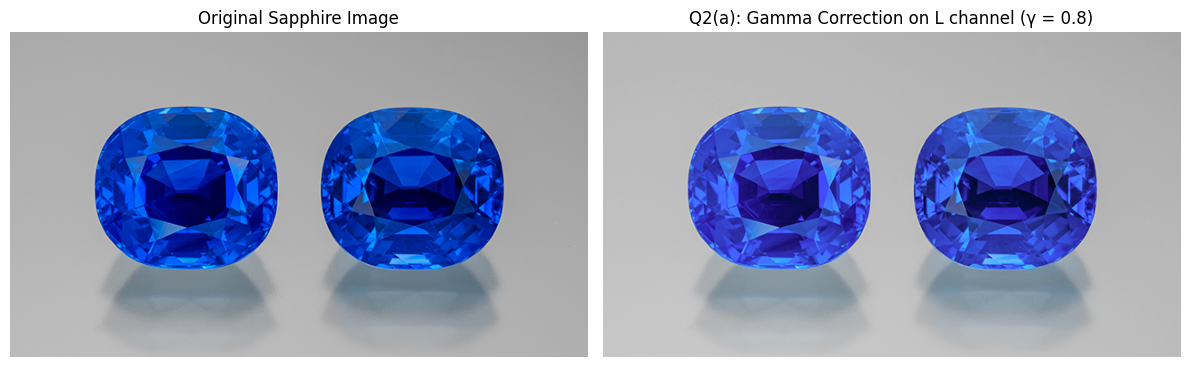

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load sapphire image (OpenCV loads in BGR)
img_bgr = cv.imread('sapphire (1).jpg')

# Convert BGR to RGB for display
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

# Convert RGB to LAB
img_lab = cv.cvtColor(img_rgb, cv.COLOR_RGB2LAB)

# Split channels
L, a, b = cv.split(img_lab)

# Normalize L channel to [0,1]
L_norm = L / 255.0

# Q2(a): gamma correction on L channel only
gamma = 0.8
L_gamma = np.power(L_norm, gamma)

# Convert back to uint8
L_gamma_u8 = np.uint8(np.clip(L_gamma * 255, 0, 255))

# Merge corrected L with original a and b
img_lab_corrected = cv.merge((L_gamma_u8, a, b))

# Convert LAB back to RGB
img_corrected_rgb = cv.cvtColor(img_lab_corrected, cv.COLOR_LAB2RGB)

# Show original and corrected images
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title('Original Sapphire Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_corrected_rgb)
plt.title('Q2(a): Gamma Correction on L channel (γ = 0.8)')
plt.axis('off')

plt.tight_layout()
plt.show()

### Optional mapping curve

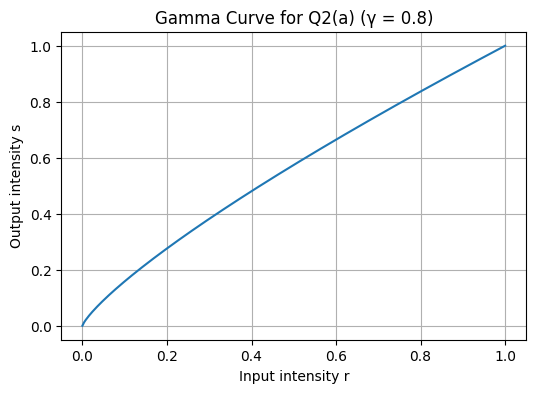

In [3]:
r = np.linspace(0, 1, 256)
s = r ** 0.8

plt.figure(figsize=(6,4))
plt.plot(r, s)
plt.title('Gamma Curve for Q2(a) (γ = 0.8)')
plt.xlabel('Input intensity r')
plt.ylabel('Output intensity s')
plt.grid(True)
plt.show()

### Python code for Q2(b) — L channel histograms

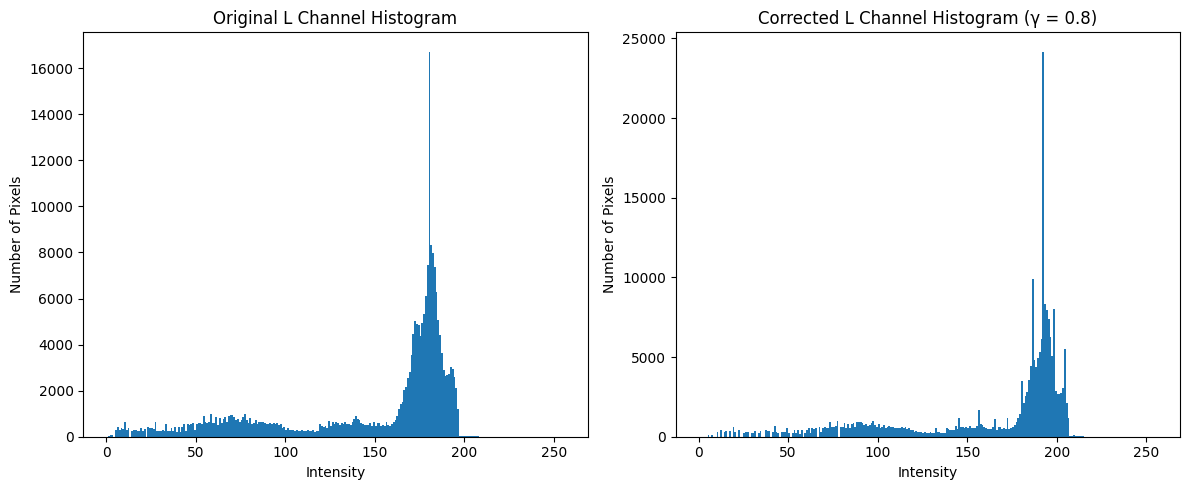

In [4]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(L.ravel(), bins=256, range=[0,256])
plt.title('Original L Channel Histogram')
plt.xlabel('Intensity')
plt.ylabel('Number of Pixels')

plt.subplot(1,2,2)
plt.hist(L_gamma_u8.ravel(), bins=256, range=[0,256])
plt.title('Corrected L Channel Histogram (γ = 0.8)')
plt.xlabel('Intensity')
plt.ylabel('Number of Pixels')

plt.tight_layout()
plt.show()

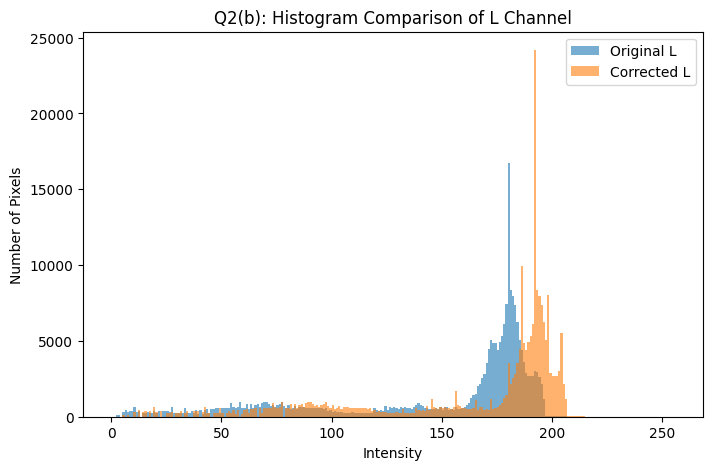

In [5]:
plt.figure(figsize=(8,5))
plt.hist(L.ravel(), bins=256, range=[0,256], alpha=0.6, label='Original L')
plt.hist(L_gamma_u8.ravel(), bins=256, range=[0,256], alpha=0.6, label='Corrected L')
plt.title('Q2(b): Histogram Comparison of L Channel')
plt.xlabel('Intensity')
plt.ylabel('Number of Pixels')
plt.legend()
plt.show()

## full visual summary for Q2

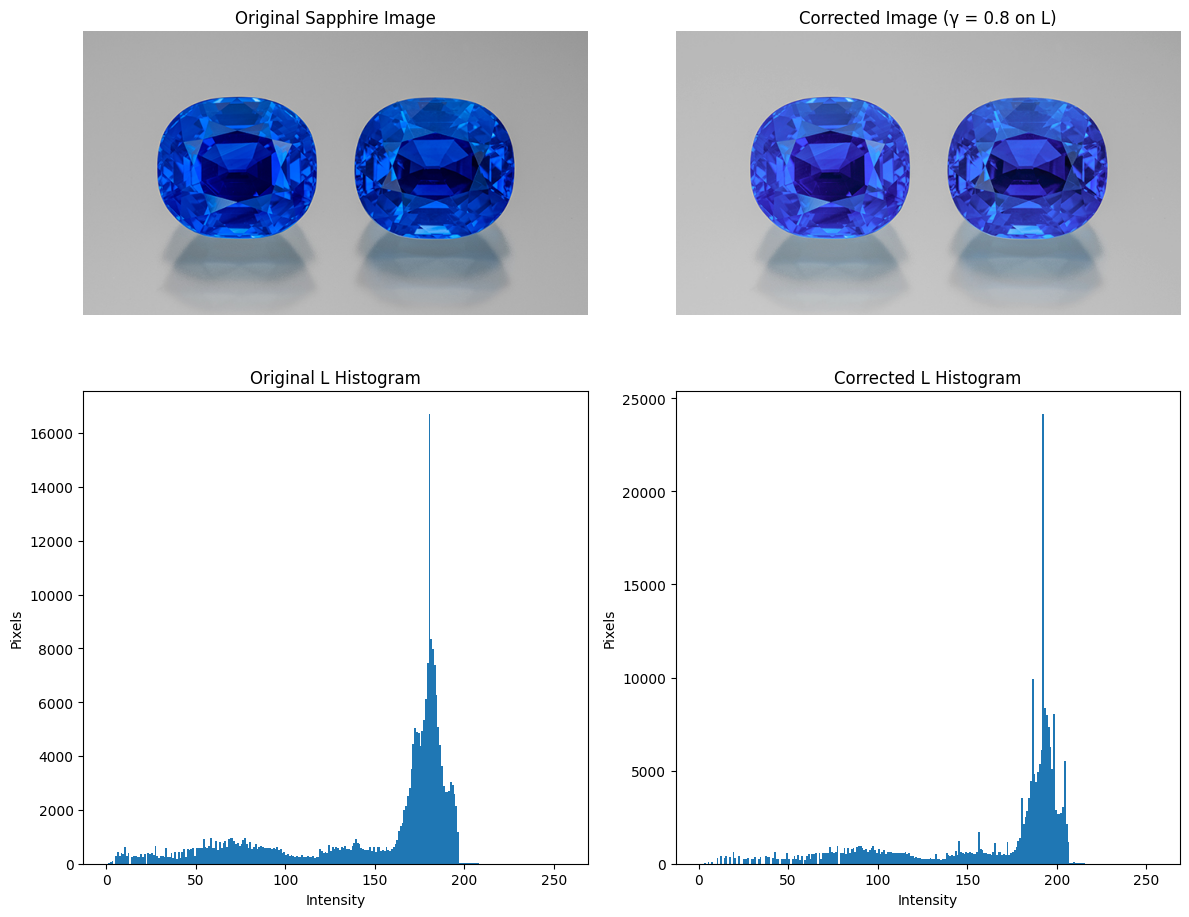

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))

axes[0,0].imshow(img_rgb)
axes[0,0].set_title('Original Sapphire Image')
axes[0,0].axis('off')

axes[0,1].imshow(img_corrected_rgb)
axes[0,1].set_title('Corrected Image (γ = 0.8 on L)')
axes[0,1].axis('off')

axes[1,0].hist(L.ravel(), bins=256, range=[0,256])
axes[1,0].set_title('Original L Histogram')
axes[1,0].set_xlabel('Intensity')
axes[1,0].set_ylabel('Pixels')

axes[1,1].hist(L_gamma_u8.ravel(), bins=256, range=[0,256])
axes[1,1].set_title('Corrected L Histogram')
axes[1,1].set_xlabel('Intensity')
axes[1,1].set_ylabel('Pixels')

plt.tight_layout()
plt.show()

#### Q2(a): The sapphire image was converted from RGB to L*a*b* color space. Gamma correction was then applied only to the L channel using γ=0.8. This choice slightly brightened the image while preserving the original color information in the a and b channels. The corrected image showed improved lightness and clearer gemstone detail without noticeable color distortion.

#### Q2(b): Histograms of the original and corrected L channels were plotted. After correction, the histogram shifted slightly toward higher intensity values, indicating increased brightness. This confirmed that the gamma transformation successfully enhanced the lightness of the image while maintaining the color characteristics of the sapphires.**